In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [10]:
comm_df = pd.read_csv('../data/communities.data', header=None)
comm_df

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,?,?,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,?,?,?,?,0.00,?,0.09
1990,6,?,?,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,?,?,?,?,0.00,?,0.45
1991,9,9,80070,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28,0.23
1992,25,17,72600,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18,0.19


In [11]:
comm_train_set = comm_df.iloc[:1495, :] 
comm_test_set = comm_df.iloc[1495:, :]

### (b) Missing values

In [12]:
comm_train = comm_train_set.iloc[:, 5:]
comm_train = comm_train.apply(pd.to_numeric, errors='coerce')

comm_test = comm_test_set.iloc[:, 5:]
comm_test = comm_test.apply(pd.to_numeric, errors='coerce')

X_train = comm_train.iloc[:, :-1]
y_train = comm_train.iloc[:, -1]
X_test = comm_test.iloc[:, :-1]
y_test = comm_test.iloc[:, -1]

In [13]:
knn_imputer = KNNImputer()
X_train_filled = pd.DataFrame(knn_imputer.fit_transform(X_train))
X_test_filled = pd.DataFrame(knn_imputer.transform(X_test))

I decided to use a KNN imputer to fill in the missing values because I wanted to preserve the local structure of the data considering that we have many features, rather then use global imputation such as the mean or median. 

### (c) Plot a correlation matrix

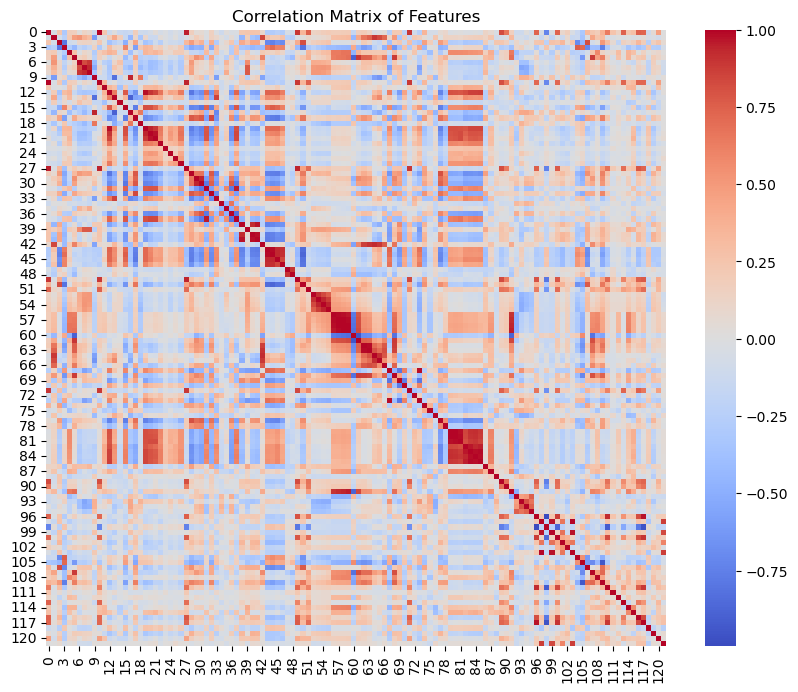

In [14]:
corr_matrix = X_train_filled.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()

From the correlation matrix above, it seems that many of the features have some level of correlation which means that some feature selection techniques could certainly benefit us in this regression task. 

### (d) Calculate the Coefficient of Variation CV

In [15]:
s = X_train_filled.std()
m = X_train_filled.mean()
CV = s/m
CV_df = pd.DataFrame({'Feature':CV.index, 'CV':CV.values}).set_index('Feature', drop=True)
CV_df

,CV
Feature,
0,2.241105
1,0.355800
2,1.428885
3,0.330213
4,1.359100
...,...
117,1.752336
118,0.157567
119,0.610092


### (e) Scatter plots and box plots for highest CV features

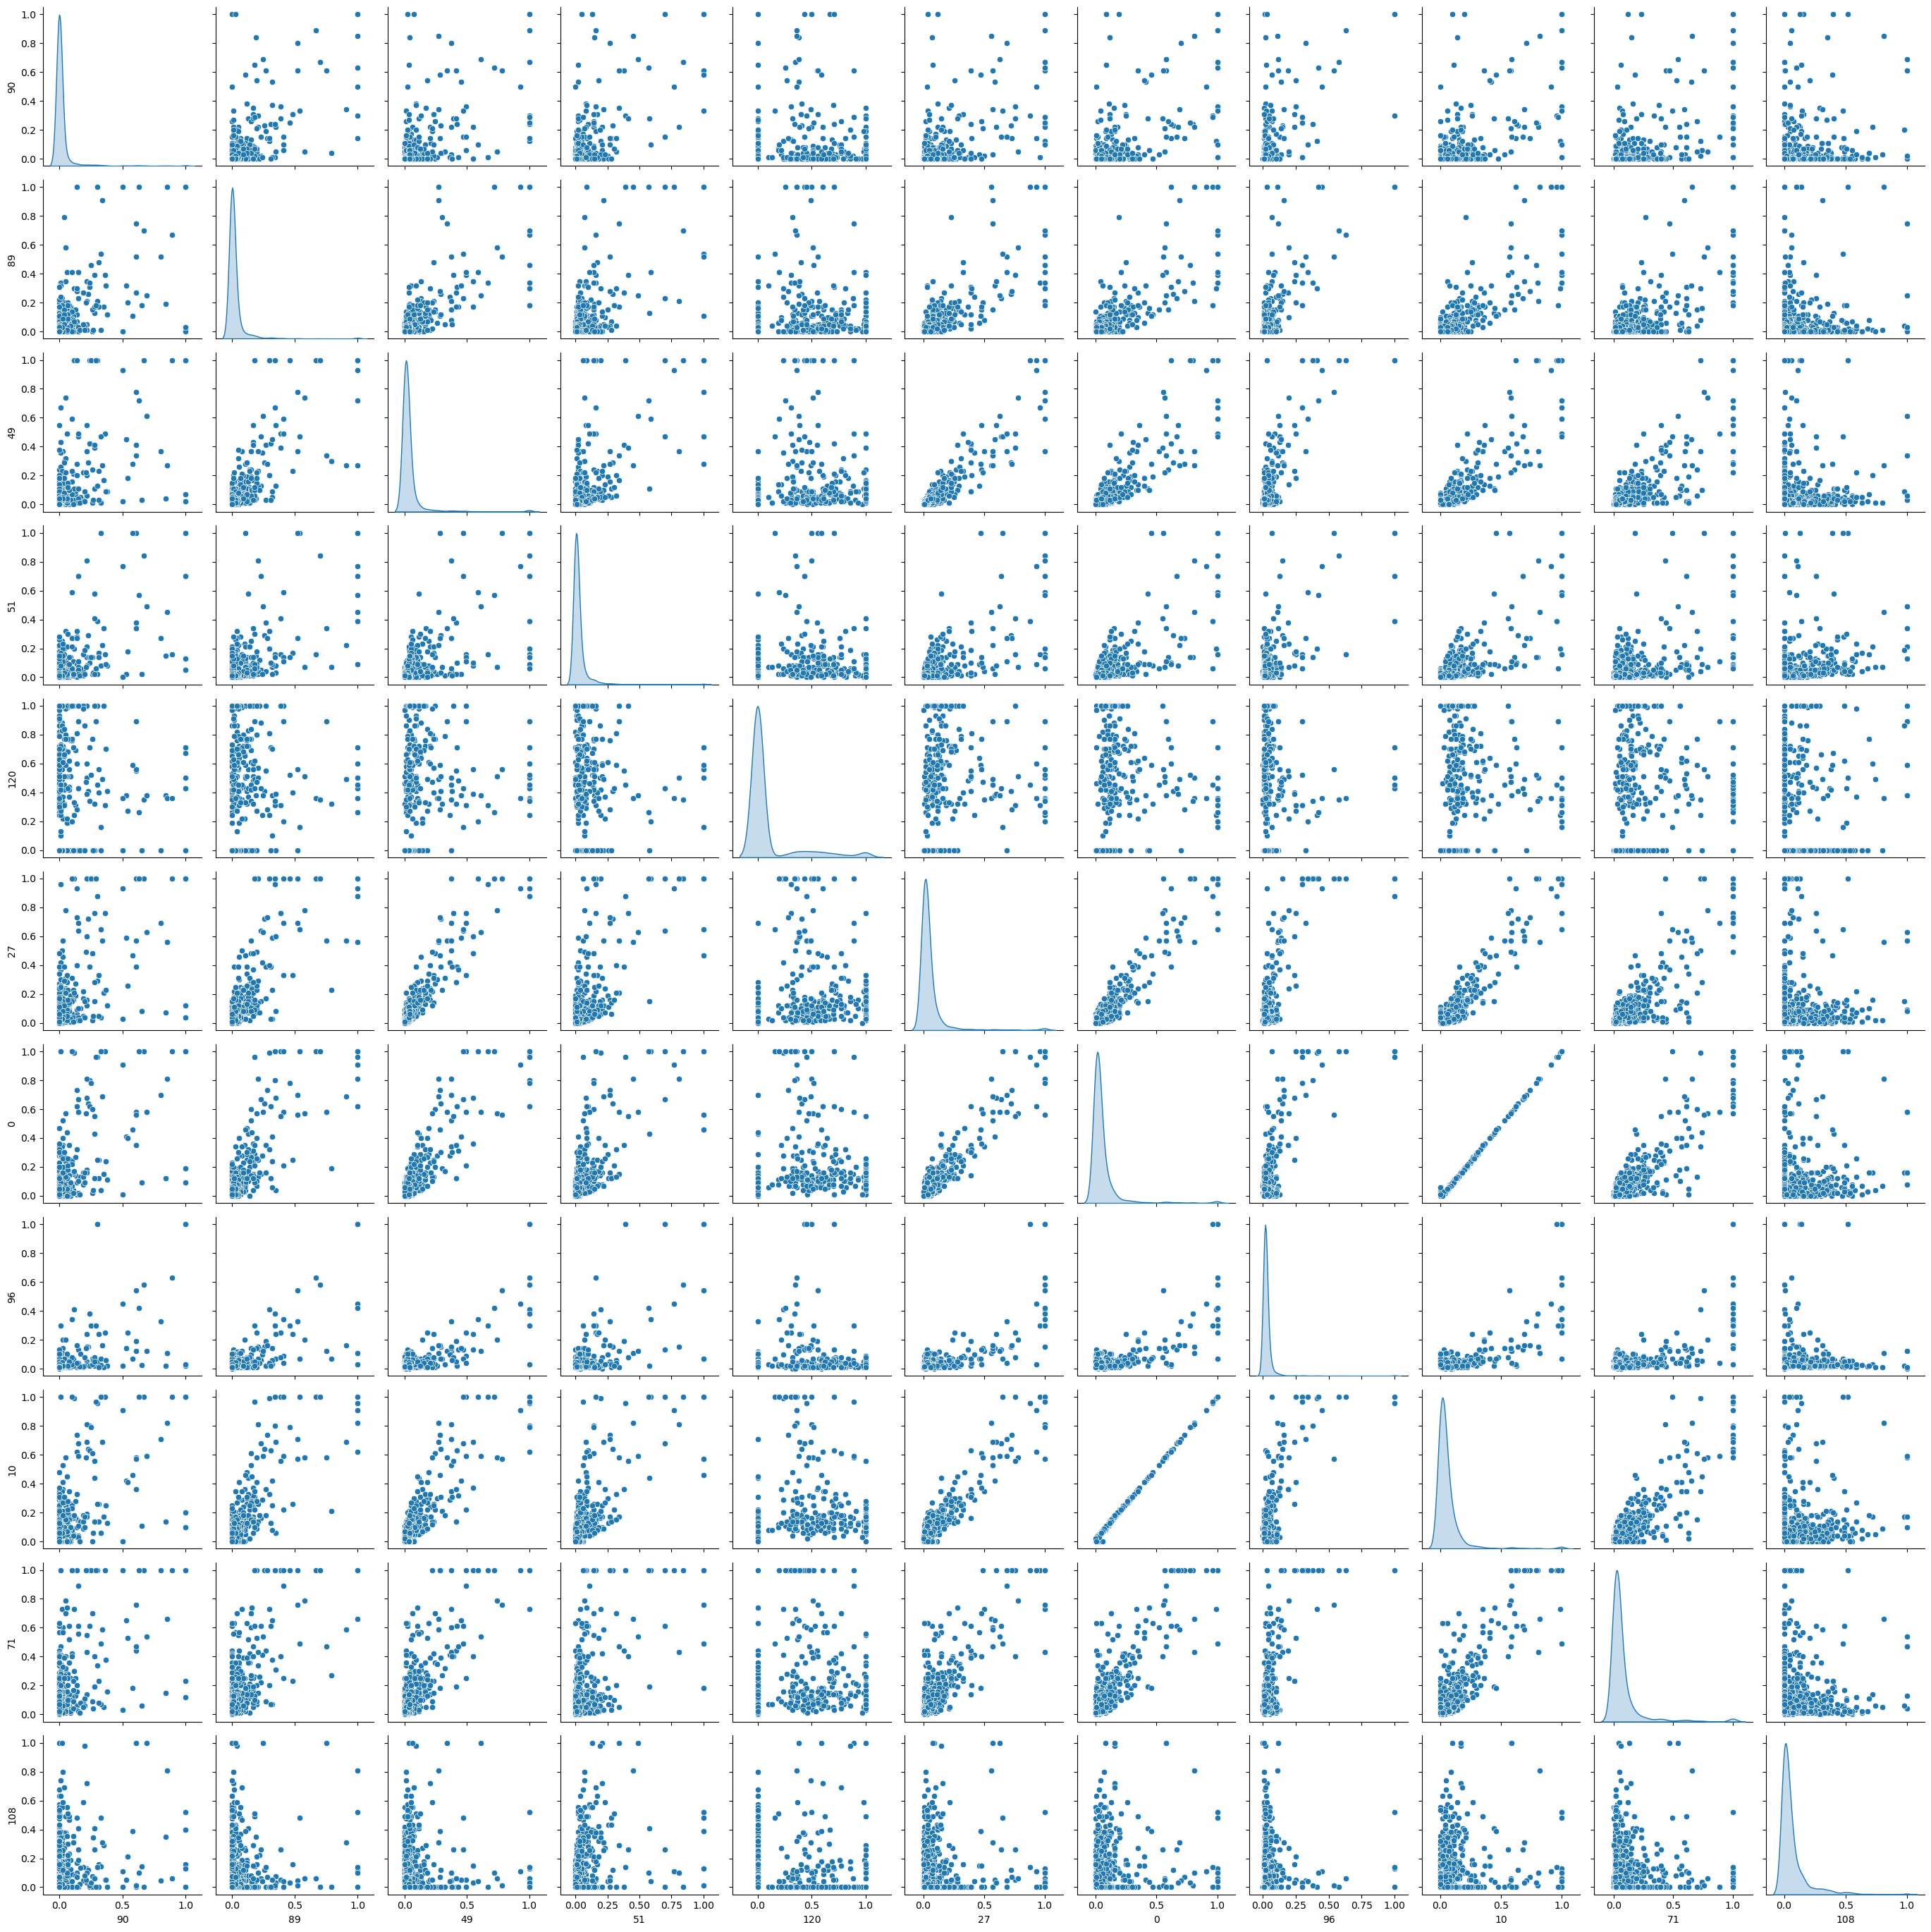

In [16]:
top_11_CV = CV_df.sort_values(by='CV', ascending=False).head(11).index.to_list()
X_train_selected = X_train_filled.loc[:, top_11_CV]
X_test_selected = X_test_filled.loc[:, top_11_CV]
sns.pairplot(X_train_selected, diag_kind='kde')
plt.tight_layout()
plt.show()

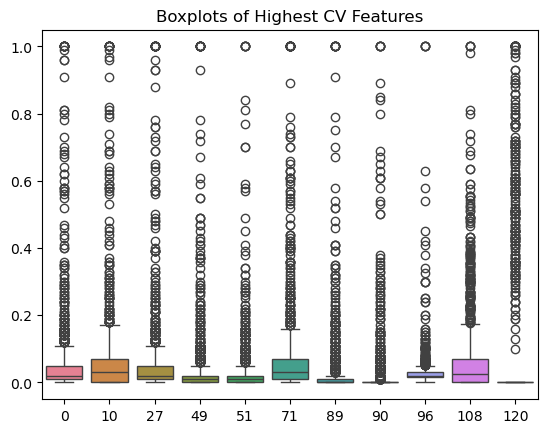

In [17]:
sns.boxplot(X_train_selected)
plt.title("Boxplots of Highest CV Features")
plt.show()

Looking at the graphs above, we can see that most of these features seem to be uncorrelated. However, some pairs of features do show some clear correlation such as features 0 and 10 which are quite strongly correlated alongside features 0 and 27 which also seem to be correlated. However, overall these feature could be fairly significant considering that they do not seem to be strongly correlated for the most part. Furthermore, when looking at the boxplots we can see that the features seem to have a majority of values closer to 0 which is also reflected in the scatterplots where most of the points are clustered close to the origin with fewer points spread around the higher values. From the boxplots, we can see that there are many outliers that could negatively affect the robustness of our linear model. Thus, some rescaling or outlier handling could possibly benefit model performance. In general, it seems that the distributions of these features are right skewed. 

### (f) Fit a linear model

In [18]:
linear_model = LinearRegression()
linear_model.fit(X_train_filled, y_train)
y_pred = linear_model.predict(X_test_filled)
least_square_mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", least_square_mse)

Mean Squared Error: 5.2743324008828755e+17


In [19]:
linear_model = LinearRegression()
linear_model.fit(X_train_selected, y_train)
y_pred = linear_model.predict(X_test_selected)
least_square_mse_selected = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', least_square_mse_selected)

Mean Squared Error: 0.029423809374241834


We can see that the linear model that uses all of the features does not perform well at all with a huge MSE. However, when we only use the highest CV features found before, we get significant improvement in the least squares regression already showing that feature selection is crucial for this regression problem. 

### (g) Fit a ridge regression model

In [20]:
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search_ridge = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_ridge.fit(X_train_filled, y_train)
best_alpha_ridge = grid_search_ridge.best_params_['alpha']
print('Best Ridge Regression Alpha:', best_alpha_ridge)

Best Ridge Regression Alpha: 1.0


In [21]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_filled, y_train)
y_pred = ridge_model.predict(X_test_filled)
ridge_mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", ridge_mse)

Mean Squared Error: 0.017402072200628484


### (h) Fit a LASSO model

In [22]:
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search_lasso = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_lasso.fit(X_train_filled, y_train)
best_alpha_lasso = grid_search_lasso.best_params_['alpha']
print('Best Lasso Regression Alpha:', best_alpha_lasso)

Best Lasso Regression Alpha: 0.01


In [23]:
lasso_model = Lasso(alpha=best_alpha_lasso)
lasso_model.fit(X_train_filled, y_train)
y_pred = lasso_model.predict(X_test_filled)
lasso_mse = mean_squared_error(y_test, y_pred)
selected_features = X_train.columns[lasso_model.coef_ != 0].tolist()
print("Selected features:", selected_features)
print("Mean Squared Error:", lasso_mse)

Selected features: [8, 49, 55]
Mean Squared Error: 0.020919681104181242


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search_lasso_scaled = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_lasso_scaled.fit(X_train_scaled, y_train)
best_alpha_lasso_scaled = grid_search_lasso_scaled.best_params_['alpha']
print('Best Lasso Regression Alpha with Standardized Features:', best_alpha_lasso_scaled)

Best Lasso Regression Alpha with Standardized Features: 0.01


In [25]:
scaled_lasso_model = Lasso(alpha=best_alpha_lasso_scaled)
scaled_lasso_model.fit(X_train_scaled, y_train)
y_pred = scaled_lasso_model.predict(X_test_scaled)
lasso_scaled_mse = mean_squared_error(y_test, y_pred)
selected_features = X_train.columns[scaled_lasso_model.coef_ != 0].tolist()
print("Selected features:", selected_features)
print("Mean Squared Error:", lasso_scaled_mse)

Selected features: [7, 8, 16, 43, 49, 53, 55, 73, 76, 77, 79, 91, 95, 106, 107, 109, 113]
Mean Squared Error: 0.017176121418421012


### (i) Fit a PCR model

,M (# of Principal Components),Mean MSE
11,12,0.021516
12,13,0.021614
13,14,0.021672
14,15,0.021824
16,17,0.022011


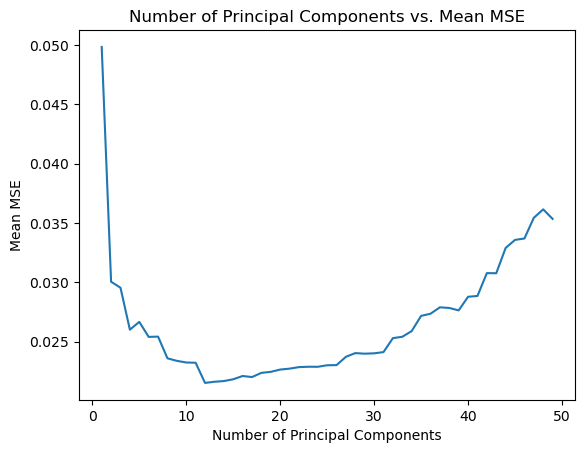

In [26]:
kfold = KFold(n_splits=5)
num_components = np.arange(1, 50, 1)
scores = {num_pc: [] for num_pc in num_components} 

for subtrain_index, val_index in kfold.split(X_train_scaled):
    X_subtrain, X_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_subtrain, y_val = y_train[train_index], y_train[val_index]

    for M in num_components:
        pca = PCA(n_components=M, random_state=24)
        X_subtrain_pca = pca.fit_transform(X_subtrain)
        X_val_pca = pca.transform(X_val)

        pcr_model = LinearRegression()
        pcr_model.fit(X_subtrain_pca, y_subtrain)
        y_pred = pcr_model.predict(X_val_pca)
        mse = mean_squared_error(y_val, y_pred)
        scores[M].append(mse)
 
average_scores = {M: np.mean(score_list) for M, score_list in scores.items()}
average_scores_df = pd.DataFrame({'M (# of Principal Components)': [M for M in scores.keys()], 'Mean MSE': [mean_mse for mean_mse in average_scores.values()]})
plt.plot(average_scores_df.iloc[:, 0], average_scores_df.iloc[:, 1])
plt.title('Number of Principal Components vs. Mean MSE')
plt.xlabel('Number of Principal Components')
plt.ylabel('Mean MSE')
average_scores_df.sort_values('Mean MSE').head()

In [27]:
pca = PCA(n_components=12, random_state=24)
pcr_model = LinearRegression()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pcr_model.fit(X_train_pca, y_train)
y_pred = pcr_model.predict(X_test_pca)
pcr_mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", pcr_mse)

Mean Squared Error: 0.01853723757311718


### (j) Fit a boosting tree

In [28]:
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search_xgb = GridSearchCV(XGBRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_xgb.fit(X_train_filled, y_train)
best_alpha_xgb = grid_search_xgb.best_params_['alpha']
print('Best Gradient Boosting Tree Alpha:', best_alpha_xgb)

Best Gradient Boosting Tree Alpha: 1.0


In [29]:
xgb_model = XGBRegressor(reg_alpha=best_alpha_xgb, random_state=24)
xgb_model.fit(X_train_filled, y_train)
y_pred = xgb_model.predict(X_test_filled)
xgb_mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", xgb_mse)

Mean Squared Error: 0.018140711785447416


In [30]:
results_df = pd.DataFrame({'Model': ['Least Squares Regression (w/ Top CV Features)', 'Ridge Regression', 'Lasso Regression', 'Lasso Regression w/ Standardized Features',  'Principal Components Regression', 'L1-Penalized Gradient Boosting Tree'],
                           'MSE': [least_square_mse_selected, ridge_mse, lasso_mse, lasso_scaled_mse, pcr_mse, xgb_mse]})
results_df

,Model,MSE
0,Least Squares Regression (w/ Top CV Features),0.029424
1,Ridge Regression,0.017402
2,Lasso Regression,0.020920
3,Lasso Regression w/ Standardized Features,0.017176
4,Principal Components Regression,0.018537
5,L1-Penalized Gradient Boosting Tree,0.018141


Looking at the performance of all of our models, we can see that the lasso regression with standardized features has the lowest MSE. This is not surprising as it will naturally perform feature selection. We saw earlier that feature selection would be crucial considering how poorly the least squares regression model performs on all features. However, the ridge regression also performs quite well likely because it shrinks the irrelevant and redundant features to almost 0. Interestingly, the ridge regression without any standard scaling performs better than the lasso regression without standard scaling. This could be because of high collinearity among features which we saw in the correlation matrix. 